# 第4章: 変数変換

## 学習目標
- 確率変数の変換と変換後の分布を理解する
- ヤコビアンを用いた密度関数の変換を習得する
- 畳み込みによる和の分布を計算できる
- 順序統計量の分布を理解する

## 📋 学習メタ情報

### 学習目標
（既存の学習目標を活用）

### 推定学習時間
**120〜150分**

### 難易度
**★★★★☆** (5段階中4)

---

## 🎯 なぜこの章を学ぶのか？

変数変換は、複雑な分布を既知の分布に変換したり、データの正規性を改善したりする重要な技法です。機械学習の前処理、モンテカルロシミュレーション、極値理論など、幅広い応用があります。

### 実世界での応用

**対数変換によるデータ正規化**: 機械学習で歪度の大きいデータを正規分布に近づけることで、モデルの性能が向上

**Box-Muller変換**: 一様乱数から正規乱数を生成する古典的手法。モンテカルロシミュレーションで使用

**極値理論**: 保険・金融で、最大損失額（最小値・最大値の分布）を予測するために使用

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.integrate import quad
import seaborn as sns

plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')
np.random.seed(42)

## 4.1 1変数の変換

### 基本公式
$Y = g(X)$ のとき、$g$ が単調なら:
$$f_Y(y) = f_X(g^{-1}(y)) \cdot \left|\frac{d}{dy}g^{-1}(y)\right|$$

### 重要な例
1. **線形変換**: $Y = aX + b$ → $f_Y(y) = \frac{1}{|a|} f_X\left(\frac{y-b}{a}\right)$
2. **二乗変換**: $Y = X^2$ (X ≥ 0) → $f_Y(y) = \frac{1}{2\sqrt{y}} f_X(\sqrt{y})$
3. **対数変換**: $Y = \log X$ → $f_Y(y) = e^y f_X(e^y)$

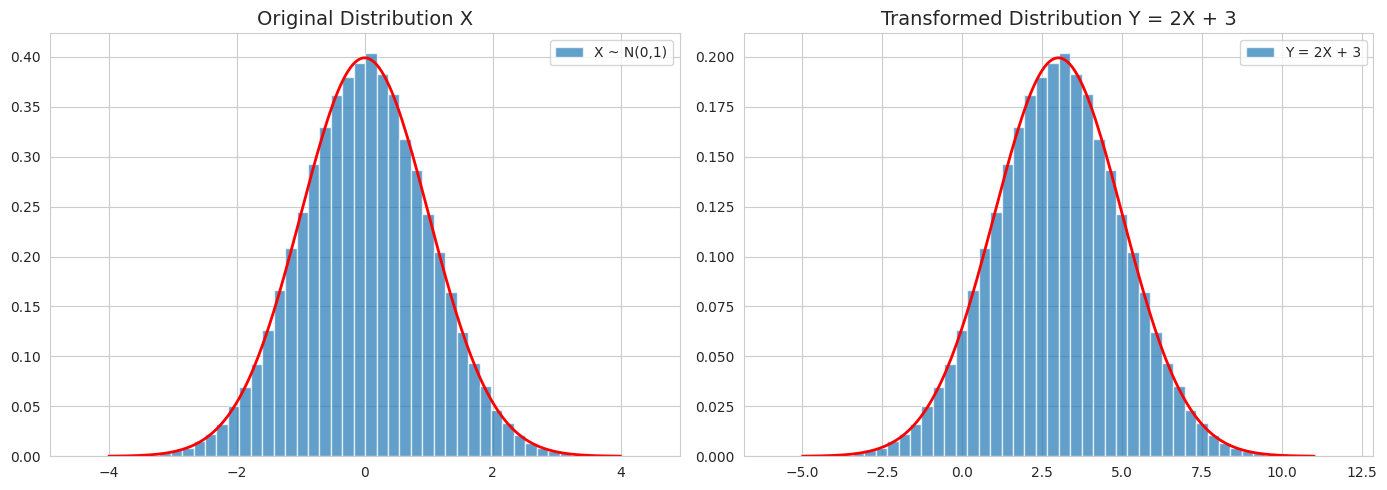

Y の理論平均: 3, シミュレーション: 3.0019
Y の理論分散: 4, シミュレーション: 4.0072


In [2]:
# 線形変換のシミュレーション
n_samples = 100000

# X ~ N(0, 1)
X = np.random.standard_normal(n_samples)

# Y = 2X + 3
a, b = 2, 3
Y = a * X + b

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# X の分布
axes[0].hist(X, bins=50, density=True, alpha=0.7, label='X ~ N(0,1)')
x_range = np.linspace(-4, 4, 200)
axes[0].plot(x_range, stats.norm.pdf(x_range), 'r-', linewidth=2)
axes[0].set_title('Original Distribution X', fontsize=14)
axes[0].legend()

# Y の分布
axes[1].hist(Y, bins=50, density=True, alpha=0.7, label=f'Y = {a}X + {b}')
y_range = np.linspace(-5, 11, 200)
# Y ~ N(b, a²) = N(3, 4)
axes[1].plot(y_range, stats.norm.pdf(y_range, b, abs(a)), 'r-', linewidth=2)
axes[1].set_title(f'Transformed Distribution Y = {a}X + {b}', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Y の理論平均: {b}, シミュレーション: {np.mean(Y):.4f}")
print(f"Y の理論分散: {a**2}, シミュレーション: {np.var(Y):.4f}")

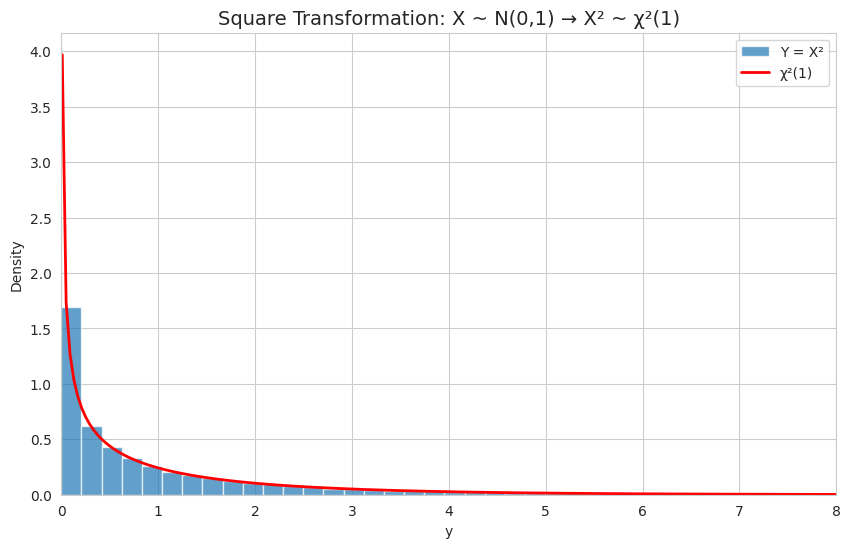

In [3]:
# 二乗変換: χ²分布の導出
# X ~ N(0, 1) → Y = X² ~ χ²(1)

X = np.random.standard_normal(n_samples)
Y = X**2

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(Y, bins=100, density=True, alpha=0.7, label='Y = X²')

# χ²(1) の理論的PDF
y_range = np.linspace(0.01, 8, 200)
ax.plot(y_range, stats.chi2.pdf(y_range, df=1), 'r-', linewidth=2, label='χ²(1)')

ax.set_title('Square Transformation: X ~ N(0,1) → X² ~ χ²(1)', fontsize=14)
ax.set_xlabel('y')
ax.set_ylabel('Density')
ax.set_xlim(0, 8)
ax.legend()
plt.show()

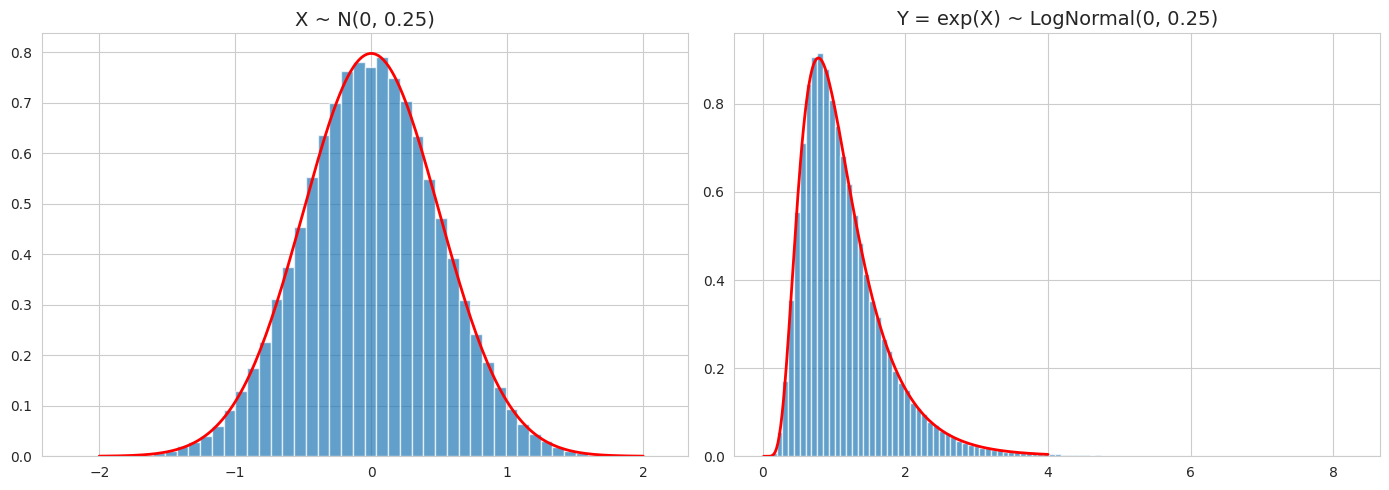

In [4]:
# 対数変換: 対数正規分布
# X ~ N(μ, σ²) → Y = e^X ~ LogNormal(μ, σ²)

mu, sigma = 0, 0.5
X = np.random.normal(mu, sigma, n_samples)
Y = np.exp(X)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# X の分布（正規）
axes[0].hist(X, bins=50, density=True, alpha=0.7)
x_range = np.linspace(-2, 2, 200)
axes[0].plot(x_range, stats.norm.pdf(x_range, mu, sigma), 'r-', linewidth=2)
axes[0].set_title(f'X ~ N({mu}, {sigma**2})', fontsize=14)

# Y の分布（対数正規）
axes[1].hist(Y, bins=100, density=True, alpha=0.7)
y_range = np.linspace(0.01, 4, 200)
axes[1].plot(y_range, stats.lognorm.pdf(y_range, s=sigma, scale=np.exp(mu)), 
             'r-', linewidth=2)
axes[1].set_title(f'Y = exp(X) ~ LogNormal({mu}, {sigma**2})', fontsize=14)

plt.tight_layout()
plt.show()

## 4.2 多変数の変換とヤコビアン

### 2変数の変換
$(X, Y) \to (U, V)$ の変換 $U = g_1(X, Y)$, $V = g_2(X, Y)$ のとき:

$$f_{U,V}(u, v) = f_{X,Y}(h_1(u,v), h_2(u,v)) \cdot |J|$$

### ヤコビアン
$$J = \det \begin{pmatrix} \frac{\partial x}{\partial u} & \frac{\partial x}{\partial v} \\ \frac{\partial y}{\partial u} & \frac{\partial y}{\partial v} \end{pmatrix}$$

または

$$|J| = \left| \det \begin{pmatrix} \frac{\partial u}{\partial x} & \frac{\partial u}{\partial y} \\ \frac{\partial v}{\partial x} & \frac{\partial v}{\partial y} \end{pmatrix} \right|^{-1}$$

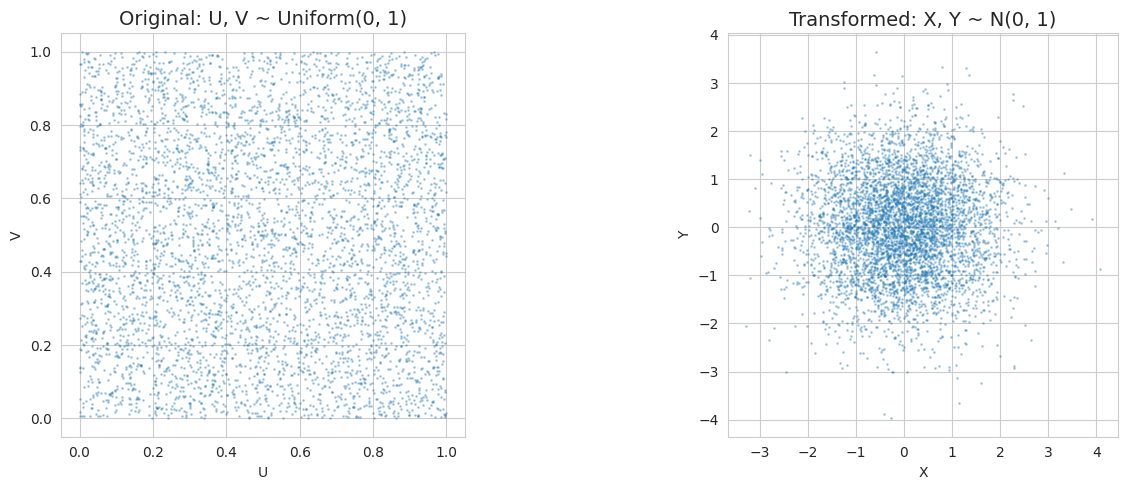

X: mean=-0.0013, var=1.0030
Y: mean=0.0030, var=0.9944
Correlation: -0.0018


In [5]:
# Box-Muller変換の例
# U, V ~ iid U(0, 1)
# X = √(-2 log U) cos(2πV)
# Y = √(-2 log U) sin(2πV)
# → X, Y ~ iid N(0, 1)

U = np.random.uniform(0, 1, n_samples)
V = np.random.uniform(0, 1, n_samples)

X = np.sqrt(-2 * np.log(U)) * np.cos(2 * np.pi * V)
Y = np.sqrt(-2 * np.log(U)) * np.sin(2 * np.pi * V)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 元の一様分布
axes[0].scatter(U[:5000], V[:5000], alpha=0.3, s=1)
axes[0].set_title('Original: U, V ~ Uniform(0, 1)', fontsize=14)
axes[0].set_xlabel('U')
axes[0].set_ylabel('V')
axes[0].set_aspect('equal')

# 変換後の正規分布
axes[1].scatter(X[:5000], Y[:5000], alpha=0.3, s=1)
axes[1].set_title('Transformed: X, Y ~ N(0, 1)', fontsize=14)
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

print(f"X: mean={np.mean(X):.4f}, var={np.var(X):.4f}")
print(f"Y: mean={np.mean(Y):.4f}, var={np.var(Y):.4f}")
print(f"Correlation: {np.corrcoef(X, Y)[0,1]:.4f}")

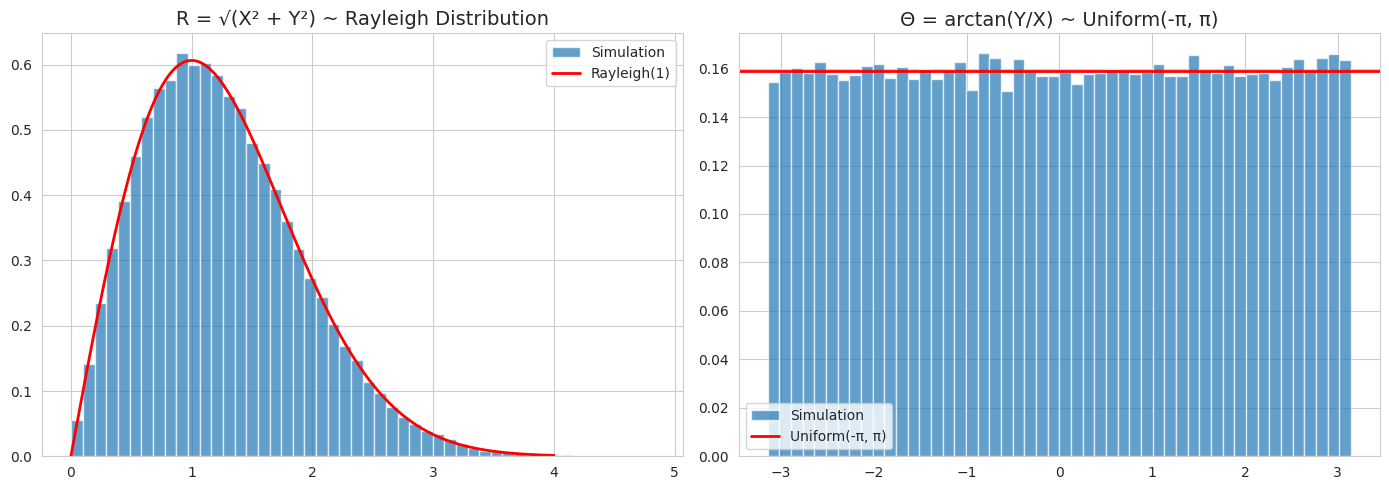

In [6]:
# 極座標変換
# (X, Y) ~ iid N(0, 1)
# R = √(X² + Y²), Θ = arctan(Y/X)
# → R² ~ χ²(2), Θ ~ U(0, 2π)

X = np.random.standard_normal(n_samples)
Y = np.random.standard_normal(n_samples)

R = np.sqrt(X**2 + Y**2)
Theta = np.arctan2(Y, X)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R の分布（レイリー分布）
axes[0].hist(R, bins=50, density=True, alpha=0.7, label='Simulation')
r_range = np.linspace(0, 4, 200)
# R ~ Rayleigh(1)、またはR² ~ χ²(2)
axes[0].plot(r_range, stats.rayleigh.pdf(r_range), 'r-', linewidth=2, 
             label='Rayleigh(1)')
axes[0].set_title('R = √(X² + Y²) ~ Rayleigh Distribution', fontsize=14)
axes[0].legend()

# Θ の分布（一様分布）
axes[1].hist(Theta, bins=50, density=True, alpha=0.7, label='Simulation')
axes[1].axhline(1/(2*np.pi), color='r', linewidth=2, label='Uniform(-π, π)')
axes[1].set_title('Θ = arctan(Y/X) ~ Uniform(-π, π)', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

## 4.3 畳み込み（和の分布）

### 定義
独立な確率変数 $X$ と $Y$ の和 $Z = X + Y$ の密度関数:

$$f_Z(z) = \int_{-\infty}^{\infty} f_X(x) f_Y(z - x) dx = (f_X * f_Y)(z)$$

### 重要な結果
1. 正規分布: $X \sim N(\mu_1, \sigma_1^2)$, $Y \sim N(\mu_2, \sigma_2^2)$ → $X + Y \sim N(\mu_1+\mu_2, \sigma_1^2+\sigma_2^2)$
2. ポアソン: $X \sim Poi(\lambda_1)$, $Y \sim Poi(\lambda_2)$ → $X + Y \sim Poi(\lambda_1+\lambda_2)$
3. ガンマ: $X \sim Gamma(\alpha_1, \beta)$, $Y \sim Gamma(\alpha_2, \beta)$ → $X + Y \sim Gamma(\alpha_1+\alpha_2, \beta)$

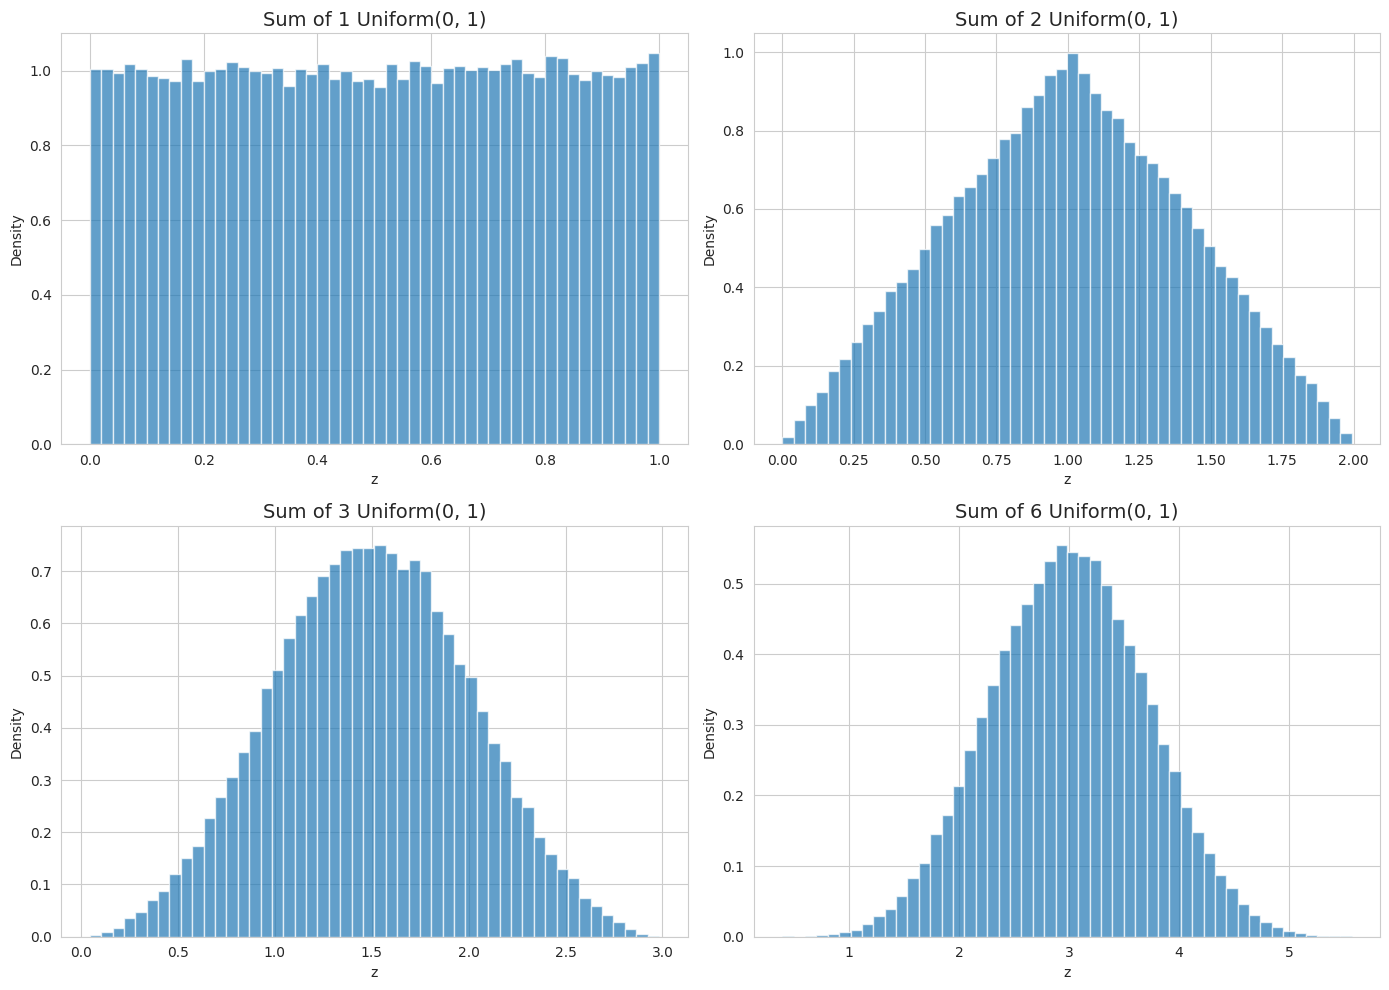

中心極限定理: 一様分布の和が正規分布に近づく


In [7]:
# 一様分布の畳み込み: Irwin-Hall分布
n_samples = 100000

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for n in [1, 2, 3, 6]:
    row, col = (n-1) // 2, (n-1) % 2
    if n > 3:
        row, col = 1, 1
    
    # n個の一様分布の和
    Z = np.sum(np.random.uniform(0, 1, (n, n_samples)), axis=0)
    
    axes[row, col].hist(Z, bins=50, density=True, alpha=0.7)
    axes[row, col].set_title(f'Sum of {n} Uniform(0, 1)', fontsize=14)
    axes[row, col].set_xlabel('z')
    axes[row, col].set_ylabel('Density')

plt.tight_layout()
plt.show()

print("中心極限定理: 一様分布の和が正規分布に近づく")

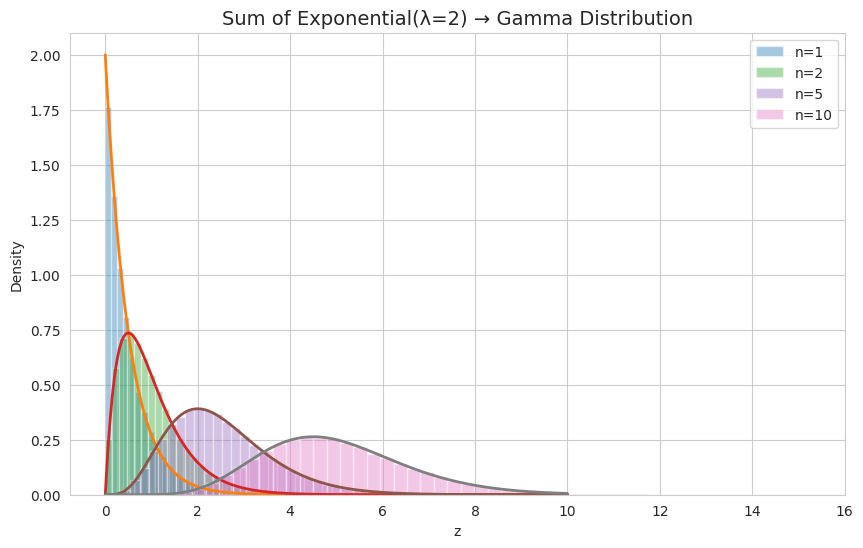

In [8]:
# 指数分布の和 → ガンマ分布
# X₁, ..., Xₙ ~ iid Exp(λ) → Σ Xᵢ ~ Gamma(n, λ)

lam = 2

fig, ax = plt.subplots(figsize=(10, 6))

for n in [1, 2, 5, 10]:
    Z = np.sum(np.random.exponential(1/lam, (n, n_samples)), axis=0)
    ax.hist(Z, bins=50, density=True, alpha=0.4, label=f'n={n}')
    
    # 理論的なガンマ分布
    z_range = np.linspace(0, 10, 200)
    ax.plot(z_range, stats.gamma.pdf(z_range, a=n, scale=1/lam), linewidth=2)

ax.set_title(f'Sum of Exponential(λ={lam}) → Gamma Distribution', fontsize=14)
ax.set_xlabel('z')
ax.set_ylabel('Density')
ax.legend()
plt.show()

## 4.4 商と積の分布

### 商の分布
$Z = X/Y$ のとき:
$$f_Z(z) = \int_{-\infty}^{\infty} |y| f_{X,Y}(zy, y) dy$$

### 重要な例
- $X, Y \sim N(0, 1)$ で独立 → $X/Y \sim Cauchy(0, 1)$
- $X \sim \chi^2(m)$, $Y \sim \chi^2(n)$ で独立 → $\frac{X/m}{Y/n} \sim F(m, n)$

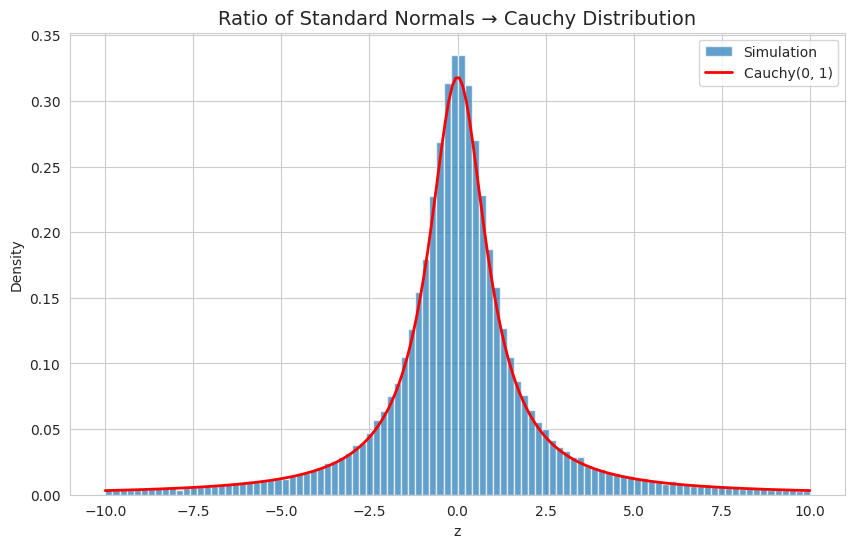

注意: コーシー分布は期待値・分散が存在しない


In [9]:
# 正規分布の商 → コーシー分布
X = np.random.standard_normal(n_samples)
Y = np.random.standard_normal(n_samples)
Z = X / Y

fig, ax = plt.subplots(figsize=(10, 6))

# 外れ値を除外して可視化
Z_trimmed = Z[np.abs(Z) < 10]
ax.hist(Z_trimmed, bins=100, density=True, alpha=0.7, label='Simulation')

# コーシー分布
z_range = np.linspace(-10, 10, 200)
ax.plot(z_range, stats.cauchy.pdf(z_range), 'r-', linewidth=2, label='Cauchy(0, 1)')

ax.set_title('Ratio of Standard Normals → Cauchy Distribution', fontsize=14)
ax.set_xlabel('z')
ax.set_ylabel('Density')
ax.legend()
plt.show()

print("注意: コーシー分布は期待値・分散が存在しない")

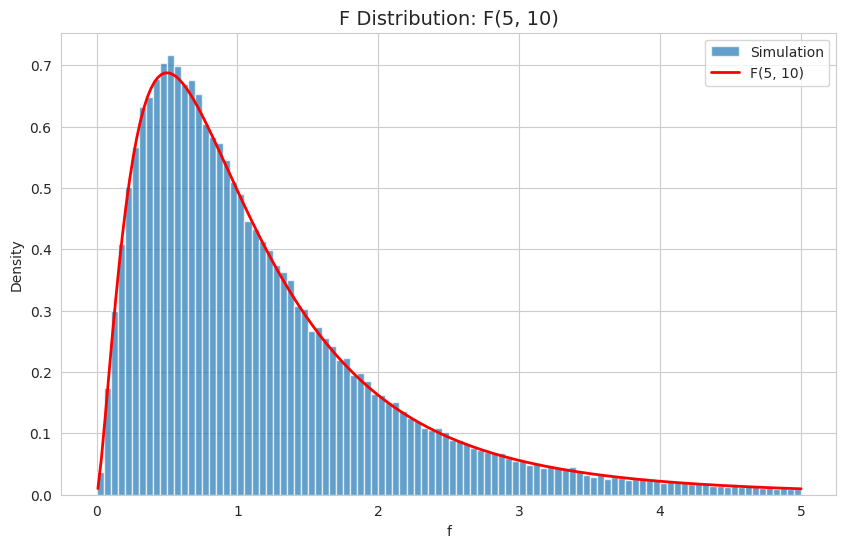

In [10]:
# F分布の導出
# F = (X/m) / (Y/n) where X ~ χ²(m), Y ~ χ²(n)

m, n = 5, 10

X = np.random.chisquare(m, n_samples)
Y = np.random.chisquare(n, n_samples)
F = (X / m) / (Y / n)

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(F, bins=100, density=True, alpha=0.7, range=(0, 5), label='Simulation')

# F分布
f_range = np.linspace(0.01, 5, 200)
ax.plot(f_range, stats.f.pdf(f_range, m, n), 'r-', linewidth=2, 
        label=f'F({m}, {n})')

ax.set_title(f'F Distribution: F({m}, {n})', fontsize=14)
ax.set_xlabel('f')
ax.set_ylabel('Density')
ax.legend()
plt.show()

## 4.5 順序統計量

### 定義
$X_1, ..., X_n$ をサンプルとし、これを小さい順に並べたものを $X_{(1)} \leq X_{(2)} \leq ... \leq X_{(n)}$ とする。

- $X_{(1)}$: 最小値
- $X_{(n)}$: 最大値
- $X_{(k)}$: $k$番目の順序統計量

### 分布関数
$$F_{X_{(k)}}(x) = \sum_{j=k}^{n} \binom{n}{j} [F(x)]^j [1-F(x)]^{n-j}$$

### 密度関数
$$f_{X_{(k)}}(x) = \frac{n!}{(k-1)!(n-k)!} [F(x)]^{k-1} [1-F(x)]^{n-k} f(x)$$

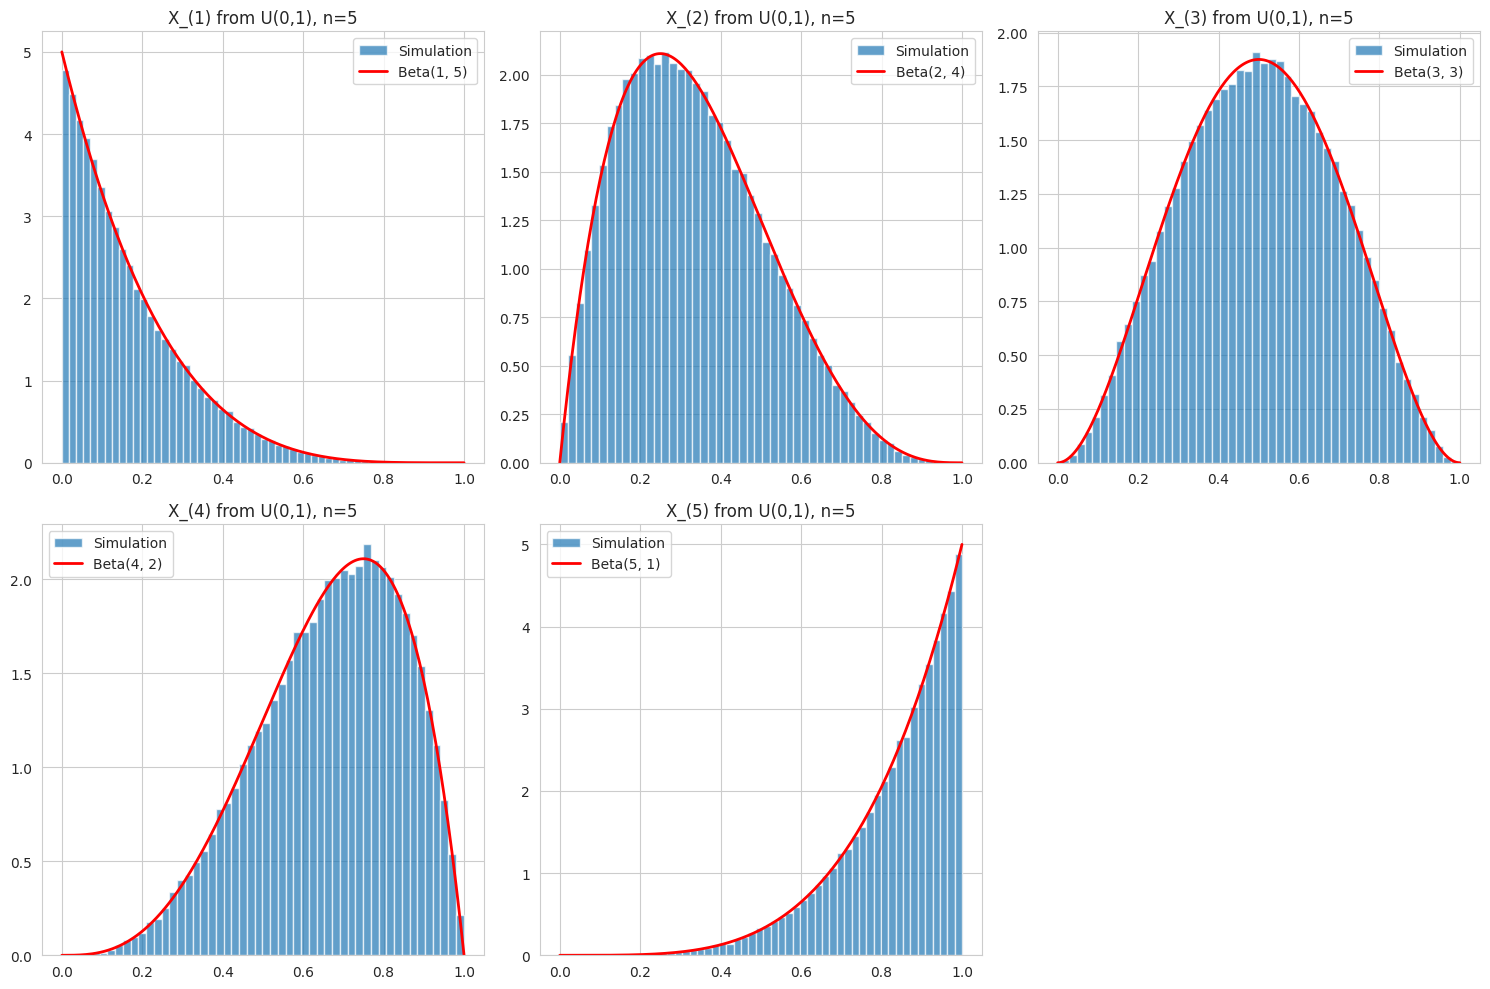

In [11]:
# 順序統計量のシミュレーション
n = 5  # サンプルサイズ
n_simulations = 100000

# 一様分布 U(0, 1) からサンプリング
samples = np.random.uniform(0, 1, (n_simulations, n))
order_stats = np.sort(samples, axis=1)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for k in range(1, n + 1):
    row, col = (k - 1) // 3, (k - 1) % 3
    
    X_k = order_stats[:, k - 1]
    
    axes[row, col].hist(X_k, bins=50, density=True, alpha=0.7, label='Simulation')
    
    # 理論的な分布: Beta(k, n-k+1)
    x_range = np.linspace(0, 1, 200)
    beta_pdf = stats.beta.pdf(x_range, k, n - k + 1)
    axes[row, col].plot(x_range, beta_pdf, 'r-', linewidth=2, 
                        label=f'Beta({k}, {n-k+1})')
    
    axes[row, col].set_title(f'X_({k}) from U(0,1), n={n}', fontsize=12)
    axes[row, col].legend()

# 空のプロット
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

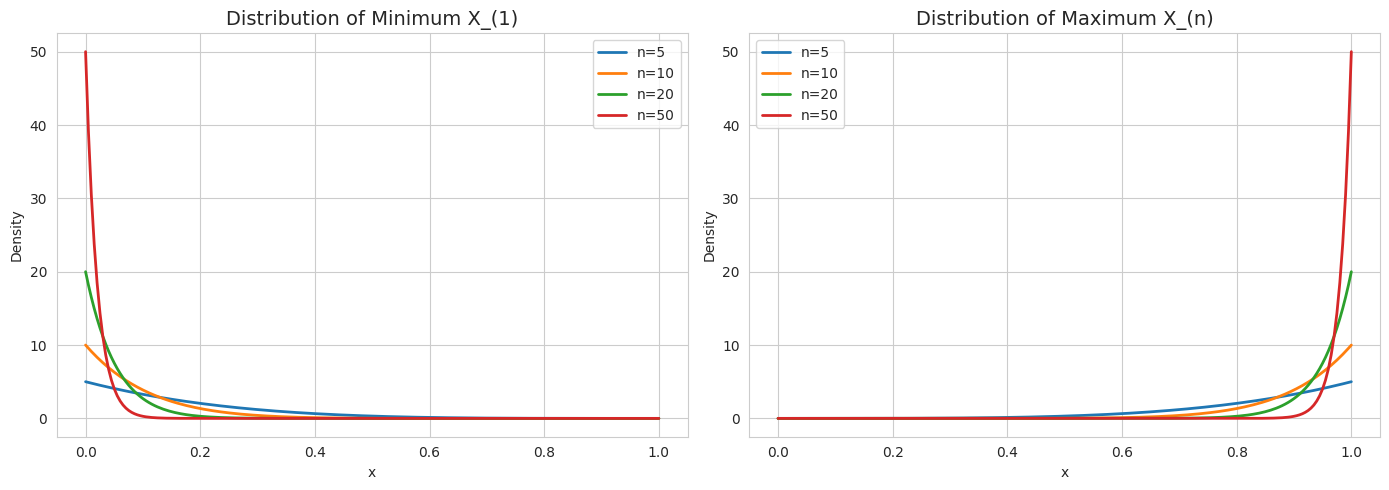

In [12]:
# 最大値と最小値の分布
n_values = [5, 10, 20, 50]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_range = np.linspace(0, 1, 200)

for n in n_values:
    # 最小値 X_(1) ~ Beta(1, n)
    min_pdf = stats.beta.pdf(x_range, 1, n)
    axes[0].plot(x_range, min_pdf, label=f'n={n}', linewidth=2)
    
    # 最大値 X_(n) ~ Beta(n, 1)
    max_pdf = stats.beta.pdf(x_range, n, 1)
    axes[1].plot(x_range, max_pdf, label=f'n={n}', linewidth=2)

axes[0].set_title('Distribution of Minimum X_(1)', fontsize=14)
axes[0].set_xlabel('x')
axes[0].set_ylabel('Density')
axes[0].legend()

axes[1].set_title('Distribution of Maximum X_(n)', fontsize=14)
axes[1].set_xlabel('x')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4.6 練習問題

### 問題1
$X \sim Exp(\lambda)$ のとき、$Y = \sqrt{X}$ の確率密度関数を求めよ。

### 問題2
$X, Y \sim$ iid $Exp(1)$ のとき、$U = X + Y$, $V = X/(X+Y)$ の同時分布を求め、$U$ と $V$ が独立であることを示せ。

### 問題3
$X_1, ..., X_n \sim$ iid $Exp(\lambda)$ のとき、$X_{(1)}$（最小値）の分布を求めよ。

問題1の解答: X ~ Exp(λ), Y = √X

f_X(x) = λe^(-λx), x ≥ 0

Y = √X → X = Y², dx/dy = 2y

f_Y(y) = f_X(y²)|dx/dy| = λe^(-λy²) · 2y
       = 2λy·e^(-λy²), y ≥ 0

これはレイリー分布に比例する形


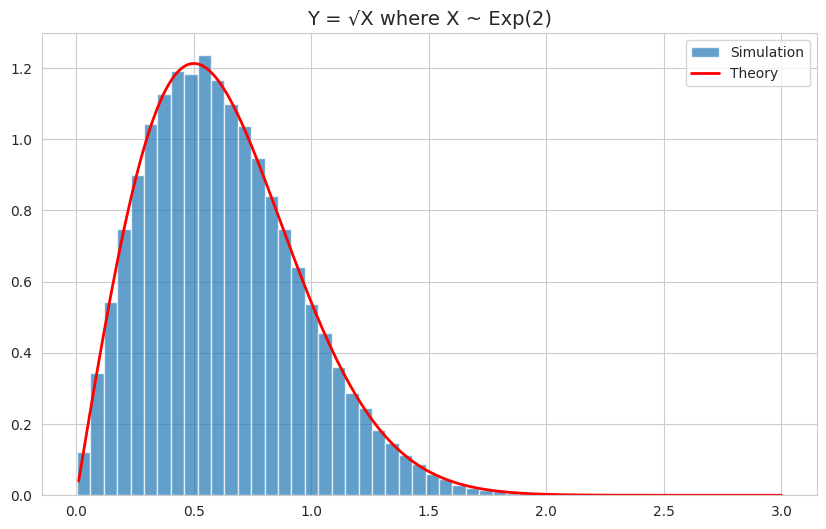

In [13]:
# 問題1の解答
print("問題1の解答: X ~ Exp(λ), Y = √X")
print("="*50)
print("\nf_X(x) = λe^(-λx), x ≥ 0")
print("\nY = √X → X = Y², dx/dy = 2y")
print("\nf_Y(y) = f_X(y²)|dx/dy| = λe^(-λy²) · 2y")
print("       = 2λy·e^(-λy²), y ≥ 0")
print("\nこれはレイリー分布に比例する形")

# シミュレーションで確認
lam = 2
X = np.random.exponential(1/lam, n_samples)
Y = np.sqrt(X)

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(Y, bins=50, density=True, alpha=0.7, label='Simulation')

y_range = np.linspace(0.01, 3, 200)
theoretical = 2 * lam * y_range * np.exp(-lam * y_range**2)
ax.plot(y_range, theoretical, 'r-', linewidth=2, label='Theory')

ax.set_title(f'Y = √X where X ~ Exp({lam})', fontsize=14)
ax.legend()
plt.show()

問題2の解答: U = X+Y, V = X/(X+Y)

X, Y ~ iid Exp(1)

ヤコビアン計算:
X = UV, Y = U(1-V)
|J| = |∂(x,y)/∂(u,v)| = |det[[v, u], [1-v, -u]]| = u

f_{U,V}(u, v) = f_X(uv)f_Y(u(1-v))|J|
              = e^(-uv) · e^(-u(1-v)) · u
              = u·e^(-u)
              = [u·e^(-u)] · [1]

よって U ~ Gamma(2, 1), V ~ Uniform(0, 1) で独立


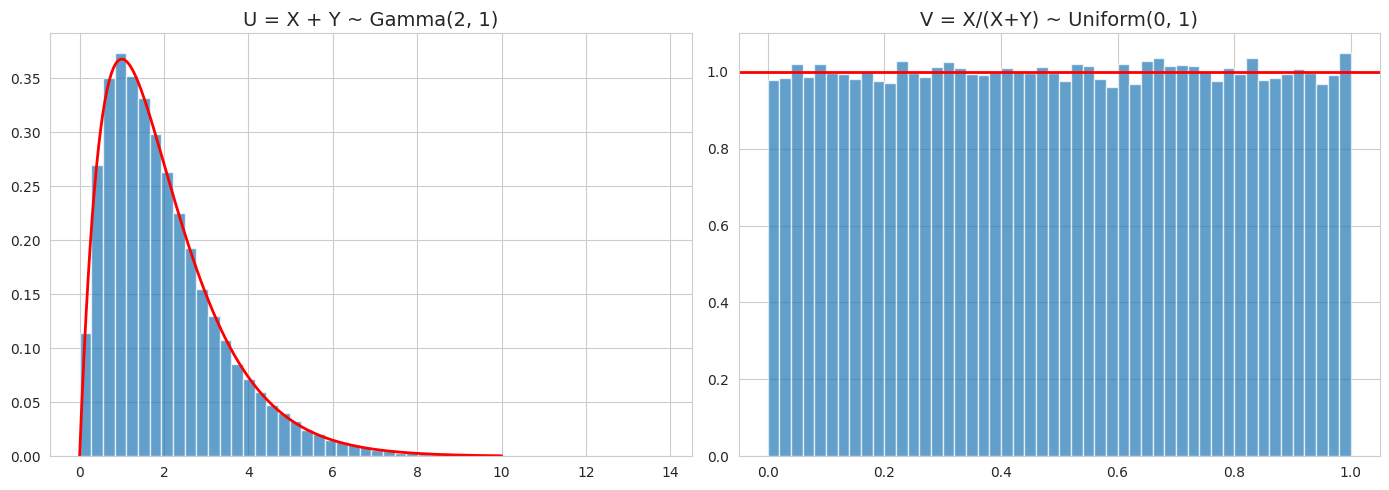


Correlation(U, V) = -0.0046 (should be ≈ 0)


In [14]:
# 問題2の解答
print("問題2の解答: U = X+Y, V = X/(X+Y)")
print("="*50)
print("\nX, Y ~ iid Exp(1)")
print("\nヤコビアン計算:")
print("X = UV, Y = U(1-V)")
print("|J| = |∂(x,y)/∂(u,v)| = |det[[v, u], [1-v, -u]]| = u")
print("\nf_{U,V}(u, v) = f_X(uv)f_Y(u(1-v))|J|")
print("              = e^(-uv) · e^(-u(1-v)) · u")
print("              = u·e^(-u)")
print("              = [u·e^(-u)] · [1]")
print("\nよって U ~ Gamma(2, 1), V ~ Uniform(0, 1) で独立")

# シミュレーション
X = np.random.exponential(1, n_samples)
Y = np.random.exponential(1, n_samples)
U = X + Y
V = X / (X + Y)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# U の分布
axes[0].hist(U, bins=50, density=True, alpha=0.7)
u_range = np.linspace(0, 10, 200)
axes[0].plot(u_range, stats.gamma.pdf(u_range, 2, scale=1), 'r-', linewidth=2)
axes[0].set_title('U = X + Y ~ Gamma(2, 1)', fontsize=14)

# V の分布
axes[1].hist(V, bins=50, density=True, alpha=0.7)
axes[1].axhline(1, color='r', linewidth=2)
axes[1].set_title('V = X/(X+Y) ~ Uniform(0, 1)', fontsize=14)

plt.tight_layout()
plt.show()

print(f"\nCorrelation(U, V) = {np.corrcoef(U, V)[0, 1]:.4f} (should be ≈ 0)")

問題3の解答: 指数分布の最小値

X₁, ..., Xₙ ~ iid Exp(λ)

P(X_(1) > x) = P(X₁ > x, ..., Xₙ > x)
            = P(X₁ > x)ⁿ (独立性)
            = (e^(-λx))ⁿ
            = e^(-nλx)

よって X_(1) ~ Exp(nλ)


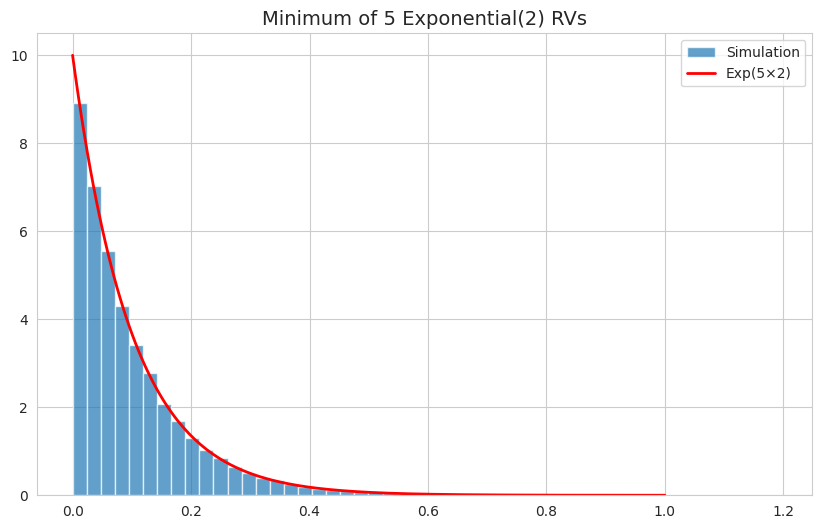


理論平均: 1/(nλ) = 0.1000
シミュレーション平均: 0.0999


In [15]:
# 問題3の解答
print("問題3の解答: 指数分布の最小値")
print("="*50)
print("\nX₁, ..., Xₙ ~ iid Exp(λ)")
print("\nP(X_(1) > x) = P(X₁ > x, ..., Xₙ > x)")
print("            = P(X₁ > x)ⁿ (独立性)")
print("            = (e^(-λx))ⁿ")
print("            = e^(-nλx)")
print("\nよって X_(1) ~ Exp(nλ)")

# シミュレーション
lam = 2
n = 5

samples = np.random.exponential(1/lam, (n_samples, n))
X_min = np.min(samples, axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(X_min, bins=50, density=True, alpha=0.7, label='Simulation')

x_range = np.linspace(0, 1, 200)
ax.plot(x_range, stats.expon.pdf(x_range, scale=1/(n*lam)), 'r-', 
        linewidth=2, label=f'Exp({n}×{lam})')

ax.set_title(f'Minimum of {n} Exponential({lam}) RVs', fontsize=14)
ax.legend()
plt.show()

print(f"\n理論平均: 1/(nλ) = {1/(n*lam):.4f}")
print(f"シミュレーション平均: {np.mean(X_min):.4f}")

## ⚠️ よくある間違いと解決策

### ❌ ヤコビアンの絶対値を忘れる
**正しい理解:** 密度関数は常に非負なので、必ず絶対値を取る
**解決策:** 公式を確認し、必ず|J|を計算する

### ❌ 単調でない変換の扱い
**正しい理解:** g(x)が単調でない場合、区間ごとに分けて計算が必要
**解決策:** 変換が単調な区間に分割してから公式を適用する

---

## 📝 理解度チェッククイズ

### 問題 1
X ~ U(0,1)のとき、Y=-ln(X)の分布は何か？

### 問題 2
2変数の変換でヤコビアンが必要な理由を説明せよ

---

## 📚 まとめ

お疲れ様でした！この章で学んだ内容は、今後の章で繰り返し使います。

---